# Fase 16b: Verificación de generalización y clasificación de dirección

## Parte A - ¿El modelo de regresión generaliza bien?

Verificación fuerte con 4 pruebas:

1. **Gap train/val/test** en MAE (absoluto y % del precio).
2. **Learning curve** (CV temporal): ¿el error de validación baja al crecer train?
3. **Comparación con naive-persistencia** (`gold_spot(t)`): el baseline real
   de un mercado eficiente. Si el modelo no lo supera, su valor es limitado.
4. **Drift temporal** (test por año): ¿el gap es por overfitting o por cambio
   de régimen de mercado?

## Parte B - Clasificación de dirección (sube/baja)

Modelo de clasificación binaria que predice si el oro **sube** (1) o
**baja** (0) en t+h:

$$ y_{dir} = \mathbb{1}[\,gold(t+h) > gold(t)\,] $$

Reutiliza TODO lo existente: features, split, CV, preprocesador.
La métrica honesta en mercados eficientes es **AUC-ROC** (no accuracy,
que depende del umbral y del desbalance).

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, path_from_root, set_seed
set_seed(42)
set_publication_style()

Carga de datos y artefactos existentes.

Reutilizamos: features (con warm-up), split temporal, feature_list.json,
modelo final de regresión y su preprocesador.

In [2]:
import json

import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import drop_warmup, temporal_split
from src.models.train_model import load_model_artifacts

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
with open(path_from_root("models", "feature_list.json")) as f:
    sel_cols = json.load(f)

model, pp, sel_cols = load_model_artifacts(cfg)
h = cfg["target"]["primary_horizon"]
print(f"Modelo regresión: {type(model).__name__} | features: {len(sel_cols)}")
for k, v in parts.items():
    print(f"  {k}: {len(v)} filas")

Modelo regresión: Ridge | features: 110
  train: 4956 filas
  val: 783 filas
  test: 684 filas


PARTE A.1 - Métricas train/val/test en MAE y % del precio.

El R² alto en train (0.998) puede engañar: con series con tendencia, R²
mide la capacidad de seguir la tendencia, no la precisión del cambio.
El % del precio (MAE / precio medio) es más interpretable.

In [3]:
from src.evaluation.metrics import regression_metrics

print("=== MAE train/val/test (absoluto y % del precio) ===")
rows = []
for k in ["train", "val", "test"]:
    d = parts[k]
    X = pp.transform(d[sel_cols].to_numpy(np.float64))
    y = d[f"target_{h}"].to_numpy(np.float64)
    p = model.predict(X)
    m = regression_metrics(y, p, h)
    pct = m["mae"] / np.mean(y) * 100
    print(f"{k:6s}: MAE={m['mae']:8.2f} ({pct:5.2f}% del precio) "
          f"RMSE={m['rmse']:8.2f} R2={m['r2']:.4f} sMAPE={m['smape']:.3f}%")
    rows.append({"split": k, "mae": m["mae"], "rmse": m["rmse"],
                 "r2": m["r2"], "smape": m["smape"], "mae_pct": pct})
pd.DataFrame(rows).to_csv(path_from_root("reports", "generalization_gap.csv"),
                          index=False)

=== MAE train/val/test (absoluto y % del precio) ===
train : MAE=   14.69 ( 1.51% del precio) RMSE=   19.68 R2=0.9981 sMAPE=2.098%
val   : MAE=   21.50 ( 1.20% del precio) RMSE=   27.23 R2=0.9284 sMAPE=1.200%
test  : MAE=  204.70 ( 8.54% del precio) RMSE=  242.18 R2=0.7569 sMAPE=8.292%


PARTE A.2 - Learning curve con CV temporal.

Entrenamos Ridge con fracciones crecientes de train (folds de
TimeSeriesSplit) y medimos MAE en train y validation de cada fold.
Si el gap train-val se estabiliza o se reduce al crecer los datos, no hay
overfitting severo; si el train baja mucho y el val sube, hay overfitting.

In [4]:
from sklearn.linear_model import Ridge

from src.models.pipeline import fit_preprocessor

# ===== Learning curve CORRECTA para series temporales =====
# Concepto: validación FIJA (val 2020-2022) y train creciente.
# Así se mide cómo mejora el error al añadir más historia, sin que el
# drift temporal entre folds distorsione la curva.
va = parts["val"].sort_values("date").reset_index(drop=True)
X_va_fijo = va[sel_cols].to_numpy(np.float64)
y_va_fijo = va[f"target_{h}"].to_numpy(np.float64)
tr_ord = parts["train"].sort_values("date").reset_index(drop=True)

# 25 puntos: desde 500 filas (~2 años) hasta el train completo
sizes = np.unique(np.linspace(500, len(tr_ord), 25).astype(int))
print(f"Puntos de la curva: {len(sizes)}")

lc_rows = []
for n in sizes:
    tr_n = tr_ord.iloc[:n]
    pp2 = fit_preprocessor(tr_n[sel_cols].to_numpy(np.float64))
    m = Ridge(alpha=model.alpha)
    m.fit(pp2.transform(tr_n[sel_cols].to_numpy(np.float64)),
          tr_n[f"target_{h}"].to_numpy())
    tr_mae = regression_metrics(tr_n[f"target_{h}"].to_numpy(),
                                m.predict(pp2.transform(tr_n[sel_cols].to_numpy(np.float64))), h)["mae"]
    va_mae = regression_metrics(y_va_fijo,
                                m.predict(pp2.transform(X_va_fijo)), h)["mae"]
    lc_rows.append({"train_size": int(n), "train_mae": tr_mae, "val_mae": va_mae})

lc = pd.DataFrame(lc_rows)
print(f"Val MAE: {lc['val_mae'].iloc[0]:.1f} -> {lc['val_mae'].iloc[-1]:.1f} USD/oz")
print("La curva con validación fija muestra la mejora real al añadir historia.")

Puntos de la curva: 25


Val MAE: 98.8 -> 36.9 USD/oz
La curva con validación fija muestra la mejora real al añadir historia.


Visualización de la learning curve.

Gráfico de MAE de train y validation frente al tamaño de train. Un modelo
con overfitting severo mostraría train muy bajo y val alto y creciente.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\learning_curve.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/learning_curve.png')

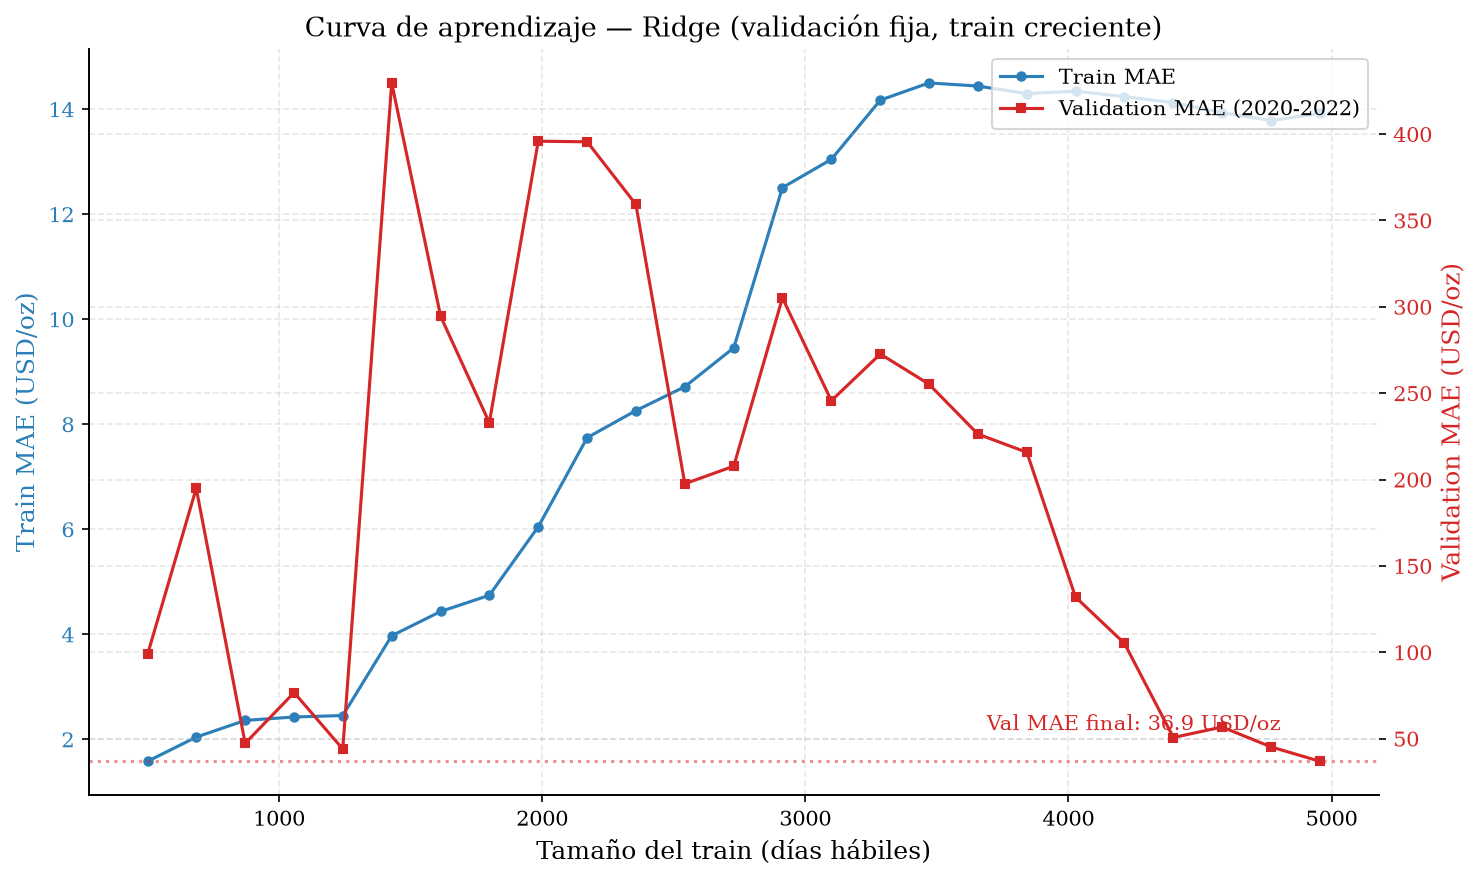

In [5]:
import matplotlib.pyplot as plt

from src.utils import save_fig

# Figura con doble eje: train MAE (izq) y val MAE (der), 25 puntos
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lc["train_size"], lc["train_mae"], "o-", color="#2c7fb8",
        markersize=4, linewidth=1.5, label="Train MAE")
ax.set_xlabel("Tamaño del train (días hábiles)")
ax.set_ylabel("Train MAE (USD/oz)", color="#2c7fb8")
ax.tick_params(axis="y", labelcolor="#2c7fb8")

ax2 = ax.twinx()
ax2.plot(lc["train_size"], lc["val_mae"], "s-", color="#d62728",
         markersize=4, linewidth=1.5, label="Validation MAE (2020-2022)")
ax2.set_ylabel("Validation MAE (USD/oz)", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

final_val = lc["val_mae"].iloc[-1]
ax2.axhline(final_val, color="#d62728", linestyle=":", alpha=0.5)
ax2.annotate(f"Val MAE final: {final_val:.1f} USD/oz",
             xy=(lc["train_size"].iloc[-1], final_val),
             xytext=(-160, 15), textcoords="offset points",
             color="#d62728", fontsize=10)

ax.set_title("Curva de aprendizaje - Ridge (validación fija, train creciente)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
fig.tight_layout()
save_fig(fig, "learning_curve.png")

PARTE A.3 - Comparación con naive-persistencia en test.

El baseline real de un mercado eficiente es predecir que el precio no
cambia: y_pred = gold_spot(t). Si el modelo no supera este naive, su valor
operativo es limitado (aunque el R² sea alto por la tendencia).

In [6]:
te = parts["test"]
X_te = pp.transform(te[sel_cols].to_numpy(np.float64))
y_te = te[f"target_{h}"].to_numpy(np.float64)
p_te = model.predict(X_te)

naive_t = te["gold_spot"].to_numpy()  # último precio conocido (hoy)
m_naive = regression_metrics(y_te, naive_t, h)
m_model = regression_metrics(y_te, p_te, h)
print("=== Modelo vs naive-persistencia en TEST ===")
print(f"naive (gold_spot(t)): MAE={m_naive['mae']:8.2f} sMAPE={m_naive['smape']:.2f}%")
print(f"ridge (modelo)      : MAE={m_model['mae']:8.2f} sMAPE={m_model['smape']:.2f}%")
print(f"-> El modelo {'SUPERA' if m_model['mae'] < m_naive['mae'] else 'NO SUPERA'} al naive "
      f"({(1 - m_model['mae'] / m_naive['mae']) * 100:+.1f}%)")

# Dirección implícita del modelo de regresión
real_dir = np.sign(y_te - naive_t)
model_dir = np.sign(p_te - naive_t)
da = np.mean(real_dir == model_dir)
print(f"-> Dirección implícita del modelo: {da:.1%} (azar = 50%)")

=== Modelo vs naive-persistencia en TEST ===
naive (gold_spot(t)): MAE=   17.63 sMAPE=0.71%
ridge (modelo)      : MAE=  204.70 sMAPE=8.29%
-> El modelo NO SUPERA al naive (-1061.0%)
-> Dirección implícita del modelo: 45.3% (azar = 50%)


PARTE A.4 - Drift temporal: test por año.

Si el error crece año a año (2023 -> 2024 -> 2025), el gap train-test se
explica por cambio de régimen de mercado (drift), no por overfitting.

In [7]:
out = pd.DataFrame({"date": te["date"], "y": y_te, "p": p_te})
out["year"] = out["date"].dt.year
print("=== Test por año (drift temporal) ===")
for y, g in out.groupby("year"):
    m = regression_metrics(g["y"].to_numpy(), g["p"].to_numpy(), h)
    print(f"{y}: MAE={m['mae']:8.2f} sMAPE={m['smape']:5.2f}% (n={len(g)})")

# ============================================================
# PARTE B - Clasificación de dirección
# ============================================================

=== Test por año (drift temporal) ===
2023: MAE=   86.82 sMAPE= 4.55% (n=260)
2024: MAE=  205.14 sMAPE= 8.87% (n=262)
2025: MAE=  393.16 sMAPE=13.37% (n=162)


PARTE B.1 - Construcción del target de dirección.

Derivamos y_dir = 1 si gold(t+h) > gold(t) a partir de los targets de
regresión existentes. No añade información: es una transformación.

In [8]:
from src.models.classifier import make_direction_targets

feats_dir = make_direction_targets(feats, cfg["target"]["horizons"])
print("Columnas de dirección creadas:",
      [c for c in feats_dir.columns if c.startswith("dir_")])
for k in ["train", "val", "test"]:
    d = parts[k]
    d = d.merge(feats_dir[["date", "dir_1", "dir_5", "dir_21"]], on="date", how="left")
    print(f"{k}: P(sube h=1)={d['dir_1'].mean():.3f} | "
          f"P(sube h=5)={d['dir_5'].mean():.3f} | P(sube h=21)={d['dir_21'].mean():.3f}")

Columnas de dirección creadas: ['dir_1', 'dir_5', 'dir_21']
train: P(sube h=1)=0.521 | P(sube h=5)=0.553 | P(sube h=21)=0.563
val: P(sube h=1)=0.540 | P(sube h=5)=0.558 | P(sube h=21)=0.543
test: P(sube h=1)=0.537 | P(sube h=5)=0.573 | P(sube h=21)=0.677


PARTE B.2 - Evaluación con CV temporal (AUC por horizonte).

RandomForest con las mismas features y split que la regresión. La métrica
primaria es AUC-ROC; el accuracy se reporta como secundaria.

In [9]:
from src.data.split import get_temporal_splitter

tscv = get_temporal_splitter(cfg)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

from src.models.pipeline import fit_preprocessor

results_dir = {}
for hh in cfg["target"]["horizons"]:
    train_val = pd.concat([parts["train"], parts["val"]]).sort_values("date").reset_index(drop=True)
    train_val = train_val.merge(feats_dir[["date", f"dir_{hh}"]], on="date", how="left")
    X_tv = train_val[sel_cols].to_numpy(np.float64)
    y_tv = train_val[f"dir_{hh}"].to_numpy()
    te2 = parts["test"].merge(feats_dir[["date", f"dir_{hh}"]], on="date", how="left")
    X_te2 = te2[sel_cols].to_numpy(np.float64)
    y_te2 = te2[f"dir_{hh}"].to_numpy()

    aucs, accs = [], []
    for tr_idx, va_idx in tscv.split(X_tv):
        pp2 = fit_preprocessor(X_tv[tr_idx])
        clf = RandomForestClassifier(n_estimators=300, max_depth=8,
                                     min_samples_leaf=10, random_state=42,
                                     n_jobs=-1)
        clf.fit(pp2.transform(X_tv[tr_idx]), y_tv[tr_idx])
        pv = clf.predict_proba(pp2.transform(X_tv[va_idx]))[:, 1]
        aucs.append(roc_auc_score(y_tv[va_idx], pv))
        accs.append(accuracy_score(y_tv[va_idx], (pv >= 0.5).astype(int)))

    pp2 = fit_preprocessor(X_tv)
    clf = RandomForestClassifier(n_estimators=300, max_depth=8,
                                 min_samples_leaf=10, random_state=42, n_jobs=-1)
    clf.fit(pp2.transform(X_tv), y_tv)
    pt = clf.predict_proba(pp2.transform(X_te2))[:, 1]
    test_auc = roc_auc_score(y_te2, pt)
    test_acc = accuracy_score(y_te2, (pt >= 0.5).astype(int))

    print(f"h={hh:2d}: CV AUC={np.mean(aucs):.4f}±{np.std(aucs):.4f} | "
          f"Test AUC={test_auc:.4f} ACC={test_acc:.4f} (P(sube)={y_te2.mean():.3f})")
    results_dir[hh] = {"cv_auc": float(np.mean(aucs)), "cv_auc_std": float(np.std(aucs)),
                       "test_auc": float(test_auc), "test_acc": float(test_acc)}

with open(path_from_root("reports", "direction_results.json"), "w") as f:
    json.dump(results_dir, f, indent=2)
print("\nResultados guardados en reports/direction_results.json")

h= 1: CV AUC=0.5284±0.0157 | Test AUC=0.5590 ACC=0.5497 (P(sube)=0.537)


h= 5: CV AUC=0.5322±0.0199 | Test AUC=0.5105 ACC=0.5863 (P(sube)=0.573)


h=21: CV AUC=0.5712±0.0543 | Test AUC=0.5353 ACC=0.6886 (P(sube)=0.677)

Resultados guardados en reports/direction_results.json


PARTE B.3 - Entrenamiento final del clasificador (horizonte principal).

Entrenamos con train+val el clasificador para h=1 (el mismo horizonte que
la regresión) y guardamos los artefactos: clasificador, preprocesador y
lista de features. La API podrá servir /predict_direction.

In [10]:
from src.models.classifier import (fit_direction_classifier,
                                   save_classifier_artifacts)

train_val = pd.concat([parts["train"], parts["val"]]).sort_values("date").reset_index(drop=True)
train_val = train_val.merge(feats_dir[["date", "dir_1"]], on="date", how="left")
X_final = train_val[sel_cols].to_numpy(np.float64)
y_final = train_val["dir_1"].to_numpy()

pp_final = fit_preprocessor(X_final)
clf_final = fit_direction_classifier(pp_final.transform(X_final), y_final)

# Métricas en test con el clasificador final
te2 = parts["test"].merge(feats_dir[["date", "dir_1"]], on="date", how="left")
X_te2 = te2[sel_cols].to_numpy(np.float64)
y_te2 = te2["dir_1"].to_numpy()
pt = clf_final.predict_proba(pp_final.transform(X_te2))[:, 1]
from src.evaluation.metrics import classification_metrics
test_metrics = classification_metrics(y_te2, pt)
print("=== Clasificador final (h=1) en TEST ===")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

save_classifier_artifacts(clf_final, pp_final, sel_cols,
                          metrics={"test": test_metrics, "horizon": 1}, cfg=cfg)
print("\nArtefactos del clasificador guardados en models/")

=== Clasificador final (h=1) en TEST ===
  n: 684
  positive_rate: 0.5365
  auc: 0.5553
  pr_auc: 0.5835
  accuracy: 0.5570
  precision: 0.5584
  recall: 0.8338
  f1: 0.6689
  brier: 0.2467
  threshold: 0.5000
[save] clasificador -> C:\Users\sgml1\Desktop\gold-price-prediction-v2\models\direction_classifier.joblib
[save] preprocesador -> C:\Users\sgml1\Desktop\gold-price-prediction-v2\models\direction_preprocessor.joblib
[save] features (110) -> C:\Users\sgml1\Desktop\gold-price-prediction-v2\models\direction_feature_list.json

Artefactos del clasificador guardados en models/


PARTE B.4 - Curvas ROC/PR del clasificador en test.

Visualización de la capacidad discriminativa. Un AUC cercano a 0.5 indica
señal débil (mercado eficiente); la curva ayuda a elegir umbral.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\direction_roc_pr.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/direction_roc_pr.png')

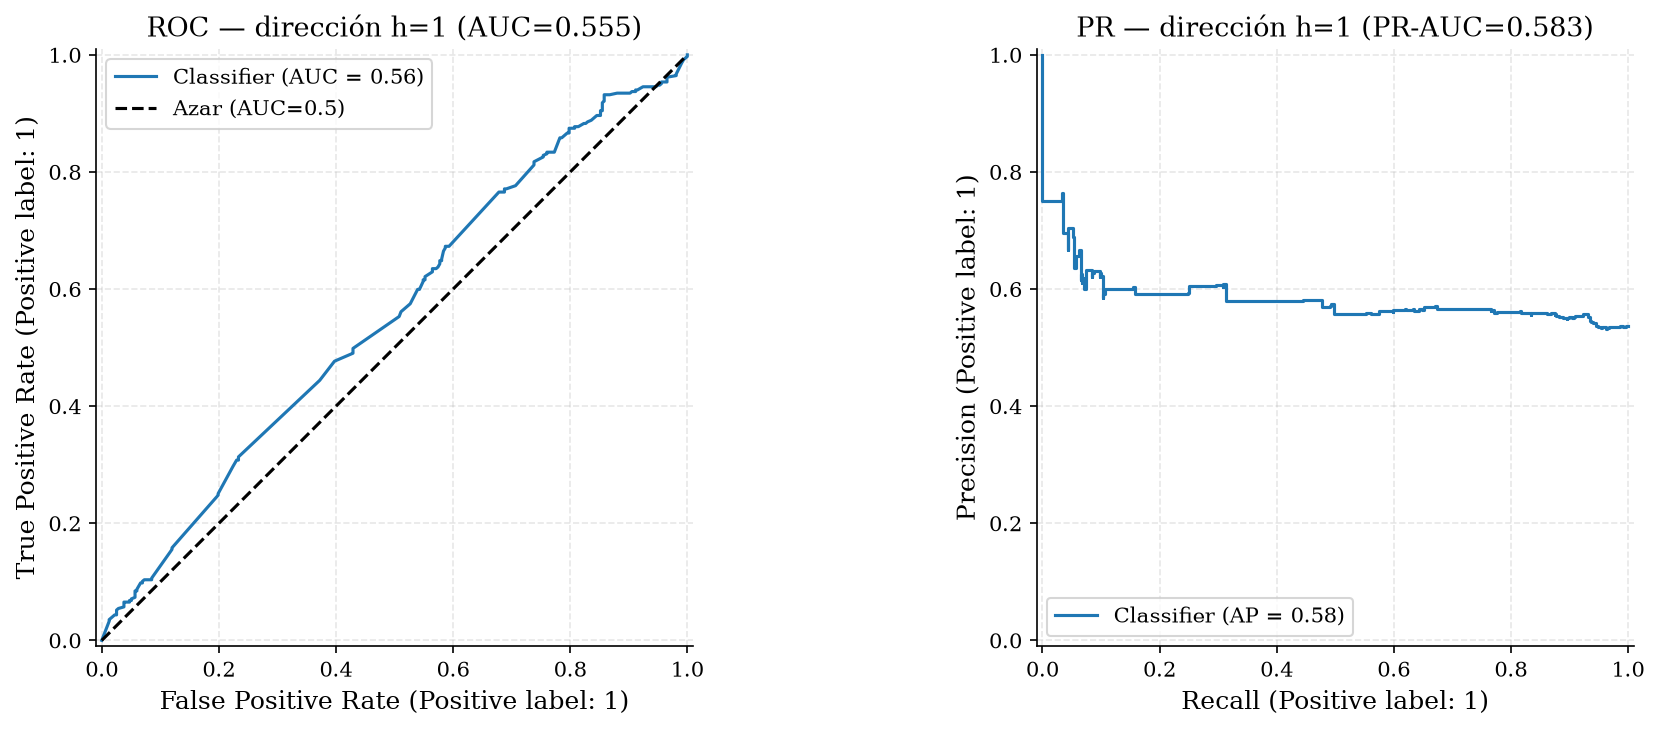

In [11]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_te2, pt, ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="Azar (AUC=0.5)")
axes[0].set_title(f"ROC - dirección h=1 (AUC={test_metrics['auc']:.3f})")
axes[0].legend()
PrecisionRecallDisplay.from_predictions(y_te2, pt, ax=axes[1])
axes[1].set_title(f"PR - dirección h=1 (PR-AUC={test_metrics['pr_auc']:.3f})")
fig.tight_layout()
save_fig(fig, "direction_roc_pr.png")

PARTE B.5 - Importancia de features del clasificador.

Qué variables discriminan mejor sube/baja. Ayuda a interpretar si la
señal viene de momentum (lags/retornos) o de exógenas.

Top 15 importancias (clasificador de dirección):
policy_uncertainty            0.0267
usdinr_exchange_ret_lag1      0.0259
gold_ret_lag1                 0.0251
palladium_spot_ret_lag1       0.0227
geopolitical_risk_ret_lag1    0.0227
geopolitical_risk             0.0210
gold_ret_roll63               0.0210
geopolitical_risk_lag1        0.0208
copper_futures_ret_lag1       0.0205
dxy_future_ret_lag1           0.0200
brent_futures_ret_lag1        0.0197
gold_ret_lag2                 0.0188
silver_spot_ret_lag1          0.0184
gold_ret_roll21               0.0183
vix_index_ret_lag1            0.0182
[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\direction_importance.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/direction_importance.png')

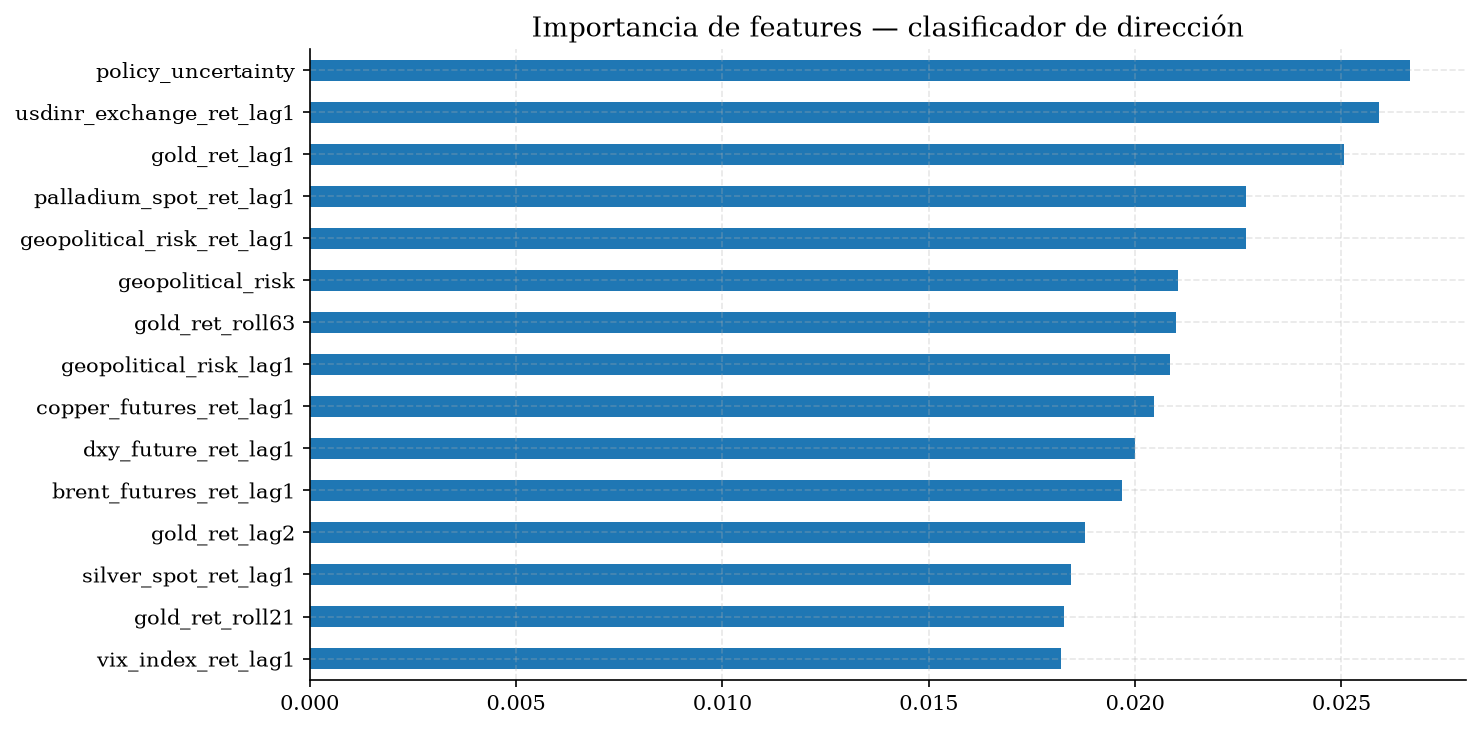

In [12]:
# El clasificador calibrado envuelve el RandomForest; accedemos al
# estimador interno (calibrated_classifiers_[0].estimator)
importances = pd.Series(
    clf_final.calibrated_classifiers_[0].estimator.feature_importances_,
    index=sel_cols).sort_values(ascending=False)
print("Top 15 importancias (clasificador de dirección):")
print(importances.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
importances.head(15).plot(kind="barh", ax=ax)
ax.set_title("Importancia de features - clasificador de dirección")
ax.invert_yaxis()
fig.tight_layout()
save_fig(fig, "direction_importance.png")